In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set(style="whitegrid")

In [8]:
np.random.seed(42)
num_students = 250


student_ids = [f"S{str(i).zfill(3)}" for i in range(1, num_students + 1)]

first_names = ["Aarav","Vivaan","Aditya","Ishaan","Sai","Ananya","Diya","Sneha","Ira","Myra"]
last_names = ["Sharma","Reddy","Kumar","Patel","Singh","Gupta","Mehta","Das","Jain","Verma"]
names = [random.choice(first_names)+" "+random.choice(last_names) for _ in range(num_students)]

genders = np.random.choice(["Male","Female"], num_students)
departments = np.random.choice(["CSE","IT","ECE"], num_students)
years = np.random.choice(["1st","2nd","3rd"], num_students)

maths_marks = np.random.randint(0,101,num_students)
science_marks = np.random.randint(0,101,num_students)
english_marks = np.random.randint(0,101,num_students)
attendance = np.random.randint(50,101,num_students)
internal_marks = np.random.randint(0,26,num_students)

df = pd.DataFrame({
    "Student_ID": student_ids,
    "Name": names,
    "Gender": genders,
    "Department": departments,
    "Year": years,
    "Maths": maths_marks,
    "Science": science_marks,
    "English": english_marks,
    "Attendance (%)": attendance,
    "Internal Marks": internal_marks
})

df.tail()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance (%),Internal Marks
245,S246,Diya Sharma,Female,CSE,1st,78,28,28,95,3
246,S247,Myra Kumar,Male,IT,1st,46,46,97,59,8
247,S248,Sneha Reddy,Male,ECE,2nd,55,67,86,92,5
248,S249,Diya Kumar,Male,ECE,1st,85,75,36,83,15
249,S250,Vivaan Kumar,Male,ECE,2nd,13,44,74,75,24


In [9]:
numeric_cols = ["Maths","Science","English","Attendance (%)","Internal Marks"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df.isnull().sum()

,0
Student_ID,0
Name,0
Gender,0
Department,0
Year,0
Maths,0
Science,0
English,0
Attendance (%),0
Internal Marks,0


In [11]:
df["Total Marks"] = df["Maths"] + df["Science"] + df["English"] + df["Internal Marks"]
df["Average Marks"] = df[["Maths","Science","English"]].mean(axis=1)

def grade(marks):
    if marks >= 85: return "A"
    elif marks >= 70: return "B"
    elif marks >= 50: return "C"
    else: return "F"

df["Grade"] = df["Average Marks"].apply(grade)

df.tail()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance (%),Internal Marks,Total Marks,Average Marks,Grade
245,S246,Diya Sharma,Female,CSE,1st,78,28,28,95,3,137,44.666667,F
246,S247,Myra Kumar,Male,IT,1st,46,46,97,59,8,197,63.000000,C
247,S248,Sneha Reddy,Male,ECE,2nd,55,67,86,92,5,213,69.333333,C
248,S249,Diya Kumar,Male,ECE,1st,85,75,36,83,15,211,65.333333,C
249,S250,Vivaan Kumar,Male,ECE,2nd,13,44,74,75,24,155,43.666667,F


In [12]:
df.describe()

,Maths,Science,English,Attendance (%),Internal Marks,Total Marks,Average Marks
count,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,50.436000,48.068000,49.25600,76.524000,12.004000,159.764000,49.253333
std,29.636857,30.293069,29.40396,14.217524,7.391245,53.126623,17.256880
min,0.000000,0.000000,0.00000,50.000000,0.000000,41.000000,11.000000
25%,25.000000,22.250000,25.00000,65.000000,5.000000,122.000000,36.750000
50%,50.500000,47.000000,48.50000,76.500000,12.000000,161.000000,49.500000
75%,76.000000,73.000000,74.00000,89.000000,17.000000,195.000000,60.916667
max,100.000000,100.000000,100.00000,100.000000,25.000000,306.000000,94.000000


In [13]:
top_students = df.nlargest(10,"Total Marks")[["Student_ID","Name","Total Marks","Grade"]]
low_performers = df[df["Grade"]=="F"][["Student_ID","Name","Total Marks","Grade"]]

print("Top 10 Students:\n", top_students)
print("\nLow Performers (Grade F):\n", low_performers)

Top 10 Students:
     Student_ID          Name  Total Marks Grade
221       S222  Aditya Reddy          306     A
232       S233  Ishaan Gupta          296     A
166       S167  Ananya Patel          278     A
151       S152    Aarav Jain          276     B
104       S105     Sai Patel          275     A
154       S155     Sneha Das          271     A
179       S180     Diya Jain          270     A
91        S092      Sai Jain          256     B
117       S118     Sai Verma          250     B
2         S003      Sai Jain          249     B

Low Performers (Grade F):
     Student_ID           Name  Total Marks Grade
0         S001   Ishaan Verma          155     F
1         S002  Vivaan Sharma          112     F
3         S004    Sneha Mehta          145     F
5         S006      Sneha Das           91     F
6         S007      Ira Mehta          117     F
..         ...            ...          ...   ...
242       S243  Ananya Sharma           54     F
243       S244       Diya Das     

In [14]:
print("Department-wise Average Marks:\n", df.groupby("Department")[["Maths","Science","English","Total Marks"]].mean())
print("\nGender-wise Average Marks:\n", df.groupby("Gender")[["Maths","Science","English","Total Marks"]].mean())
print("\nYear-wise Average Marks:\n", df.groupby("Year")[["Maths","Science","English","Total Marks"]].mean())

Department-wise Average Marks:
                 Maths    Science    English  Total Marks
Department                                              
CSE         51.916667  49.416667  51.345238   165.380952
ECE         45.268293  48.414634  47.414634   153.365854
IT          54.000000  46.380952  48.964286   160.392857

Gender-wise Average Marks:
             Maths    Science    English  Total Marks
Gender                                              
Female  47.798387  46.201613  50.467742   156.733871
Male    53.031746  49.904762  48.063492   162.746032

Year-wise Average Marks:
           Maths    Science    English  Total Marks
Year                                              
1st   50.580000  43.990000  51.170000   157.170000
2nd   47.782051  48.012821  45.500000   153.384615
3rd   53.111111  53.791667  50.666667   170.277778


/tmp/ipykernel_519/1472177136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Grade", data=df, palette="Set2")


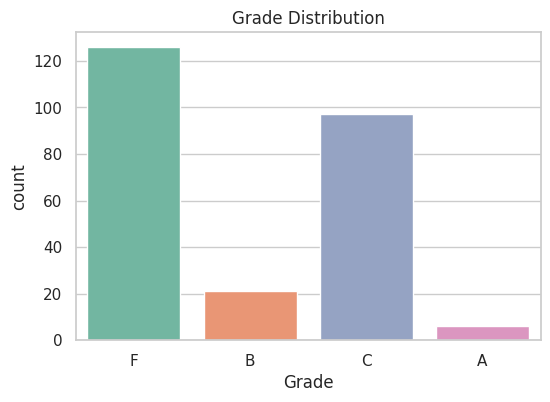

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Grade", data=df, palette="Set2")
plt.title("Grade Distribution")
plt.show()

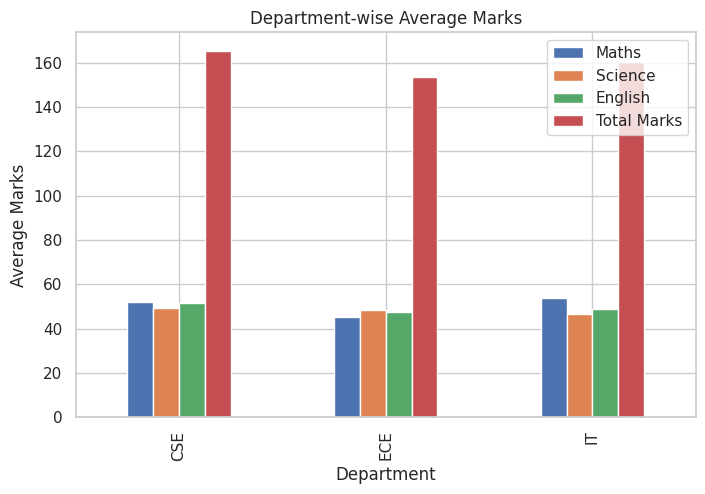

In [16]:
df.groupby("Department")[["Maths","Science","English","Total Marks"]].mean().plot(kind="bar", figsize=(8,5))
plt.title("Department-wise Average Marks")
plt.ylabel("Average Marks")
plt.show()

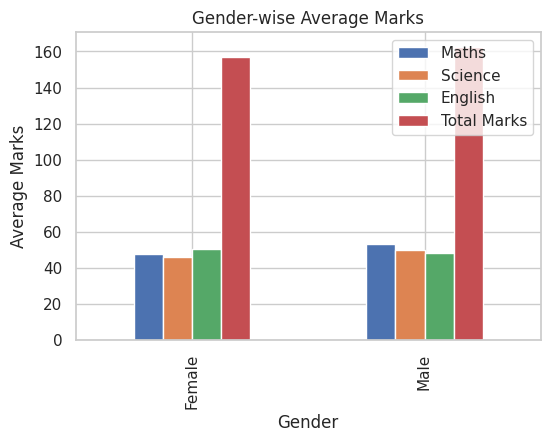

In [17]:
df.groupby("Gender")[["Maths","Science","English","Total Marks"]].mean().plot(kind="bar", figsize=(6,4))
plt.title("Gender-wise Average Marks")
plt.ylabel("Average Marks")
plt.show()

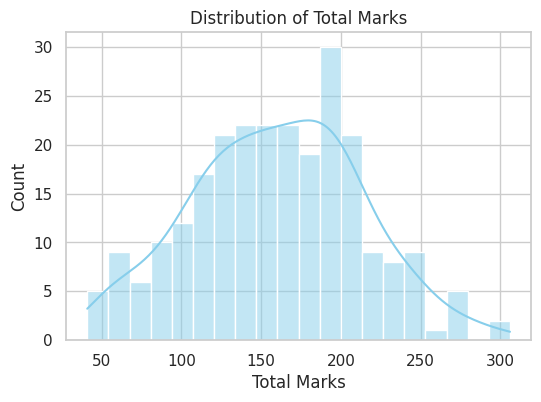

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df["Total Marks"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Total Marks")
plt.show()

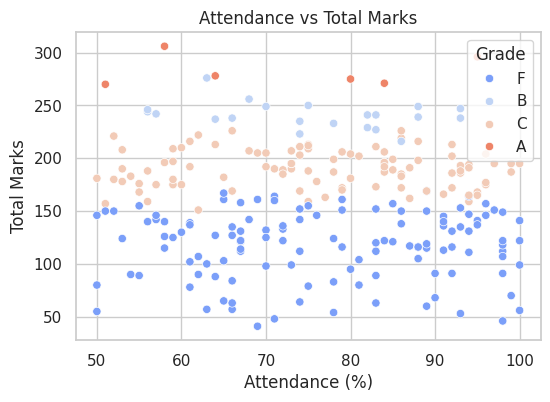

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Attendance (%)", y="Total Marks", data=df, hue="Grade", palette="coolwarm")
plt.title("Attendance vs Total Marks")
plt.show()

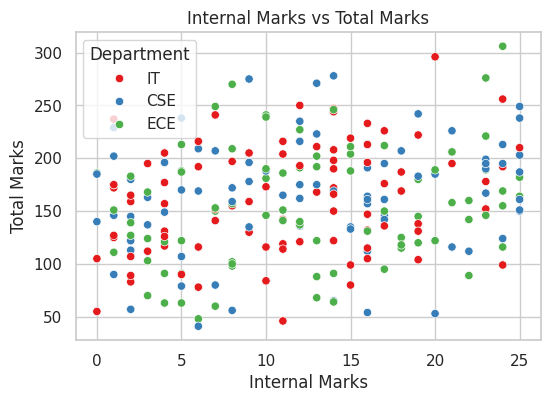

In [20]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Internal Marks", y="Total Marks", data=df, hue="Department", palette="Set1")
plt.title("Internal Marks vs Total Marks")
plt.show()

In [21]:
print("✅ Project Completed: Student Performance Analysis Done Successfully!")

✅ Project Completed: Student Performance Analysis Done Successfully!
